# Infer Class

In [1]:
import sys
sys.path.append('AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/src/lib')
import json
import os
from copy import deepcopy
from utils.eval_utils import coco_into_labels, Table, pairTab, TabUnit
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
import numpy as np
import argparse
from tqdm import tqdm
import pycocotools.coco as coco
from opts import opts
from detectors.detector_factory import detector_factory
from PIL import Image
import shapely
import itertools
from shapely import Polygon
import cv2

In [2]:
class TableStructureRec():
    def __init__(self, cfg):
        self.cfg = cfg
        self.lore_detector = detector_factory['ctdet'](self.cfg)

    def get_table_structure(self, img_path, visualize=False):
        res = {'polygons':[], 'boxes':[]}
        ret = self.lore_detector.run(self.cfg, img_path)
        ret['logi'] = ret['logi'].cpu().detach().numpy().astype(int)
        res['polygons'] = ret['4ps'][1][:len(ret['logi']), :]
        res['boxes'] = ret['logi'][res['polygons'][:, -1] > self.cfg.cell_thresh, :]
        res['polygons'] = res['polygons'][res['polygons'][:, -1] > self.cfg.cell_thresh, :-1]
        
        visualize_img = None
        if visualize:
            img = cv2.imread(img_path)
            visualize_img = self.plot_result(img, res)
        
        return res, visualize_img

    def plot_result(self, image, result):
        output_image = image.copy()
    
        isClosed = True
        color = (255, 0, 0)
        thickness = 1
        isClosed = True
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.4
        text_size, _ = cv2.getTextSize('R', font, font_scale, thickness)
        line_height = text_size[1] + 2
        
        for points, logi in zip(result['polygons'], result['boxes']):
            pts = np.array(points).reshape((-1, 1, 2)).astype(int)
            points = np.array(points).reshape((4, 2)).astype(int)
            
            output_image = cv2.polylines(output_image, [pts],  isClosed, color, thickness)
            
            r_text = f"R{logi[0]}:{logi[1]}"
            c_text = f"C{logi[2]}:{logi[3]}"
            center = np.mean(points, axis=0).astype(int)
            output_image = cv2.putText(output_image, r_text, (center[0]-5, center[1]), font, font_scale, color, thickness, cv2.LINE_AA)
            output_image = cv2.putText(output_image, c_text, (center[0]-5, center[1]+line_height), font, font_scale, color, thickness, cv2.LINE_AA)
        return output_image

Output của TableStructureRec có dạng:
    {
    'polygons': [<bounding box of cell 1> , 
                 <bounding box of cell 2>,...],
    'boxes': [<logic position of cell 1>,
              <logic position of cell 2>,...]
    }

Bounding box của 1 cell có dạng [x0, y0, x1, y1]

In [ ]:
opt = opts()
opt=opt.init(['ctdet', 
           '--dataset_name', 'WTW',
           '--load_model', 'AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/exp/ctdet/finetune2/model_best.pth',
           '--load_processor', 'AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/exp/ctdet/finetune2/processor_best.pth',
           '--tsfm_layers', '4',
           '--stacking_layers', '4'
           ''])
opt.cell_thresh = 0.001
opt.wiz_4ps = True
opt.wiz_stacking = True
opt.wiz_rev = True
opt.wiz_detect = True
opt.nms  = False
opt.K = 3000 
opt.MK = 5000 

In [4]:
rec = TableStructureRec(opt)

****identify network
****load backbone
loaded AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/exp/ctdet/finetune2/model_best.pth, epoch 85
loaded AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/exp/ctdet/finetune2/processor_best.pth, epoch 85


In [5]:
x, plot_img =rec.get_table_structure('data/'+'cantho/z3295967844623_60e2f2e91bc308a008ea6d21b2f11d9d.jpg', visualize=True)
x

{'polygons': array([[ 583.12396 ,  685.874   ,  687.74634 , ...,  720.7489  ,
          583.1238  ,  720.74963 ],
        [ 583.1251  ,  650.9996  ,  687.74805 , ...,  685.87244 ,
          583.12396 ,  685.874   ],
        [ 809.811   ,  616.1236  ,  949.315   , ...,  650.99835 ,
          809.8106  ,  650.9984  ],
        ...,
        [  71.626   ,  755.62537 ,  129.75386 , ...,  790.50397 ,
           71.624626,  790.49976 ],
        [  71.60806 ,  959.05414 , 1030.6821  , ...,  993.9279  ,
          133.20987 ,  990.75543 ],
        [  71.61917 ,  993.9371  , 1114.3641  , ..., 1028.8104  ,
          118.691605, 1028.8455  ]], dtype=float32),
 'boxes': array([[11, 11,  3,  3],
        [10, 10,  3,  3],
        [ 9,  9,  5,  5],
        [ 0,  0,  5,  5],
        [ 3,  3,  4,  4],
        [ 2,  2,  1,  1],
        [10, 10,  5,  5],
        [ 9,  9,  3,  3],
        [ 2,  2,  4,  4],
        [ 1,  1,  5,  5],
        [ 4,  4,  4,  4],
        [11, 11,  5,  5],
        [ 1,  1,  3,  3],

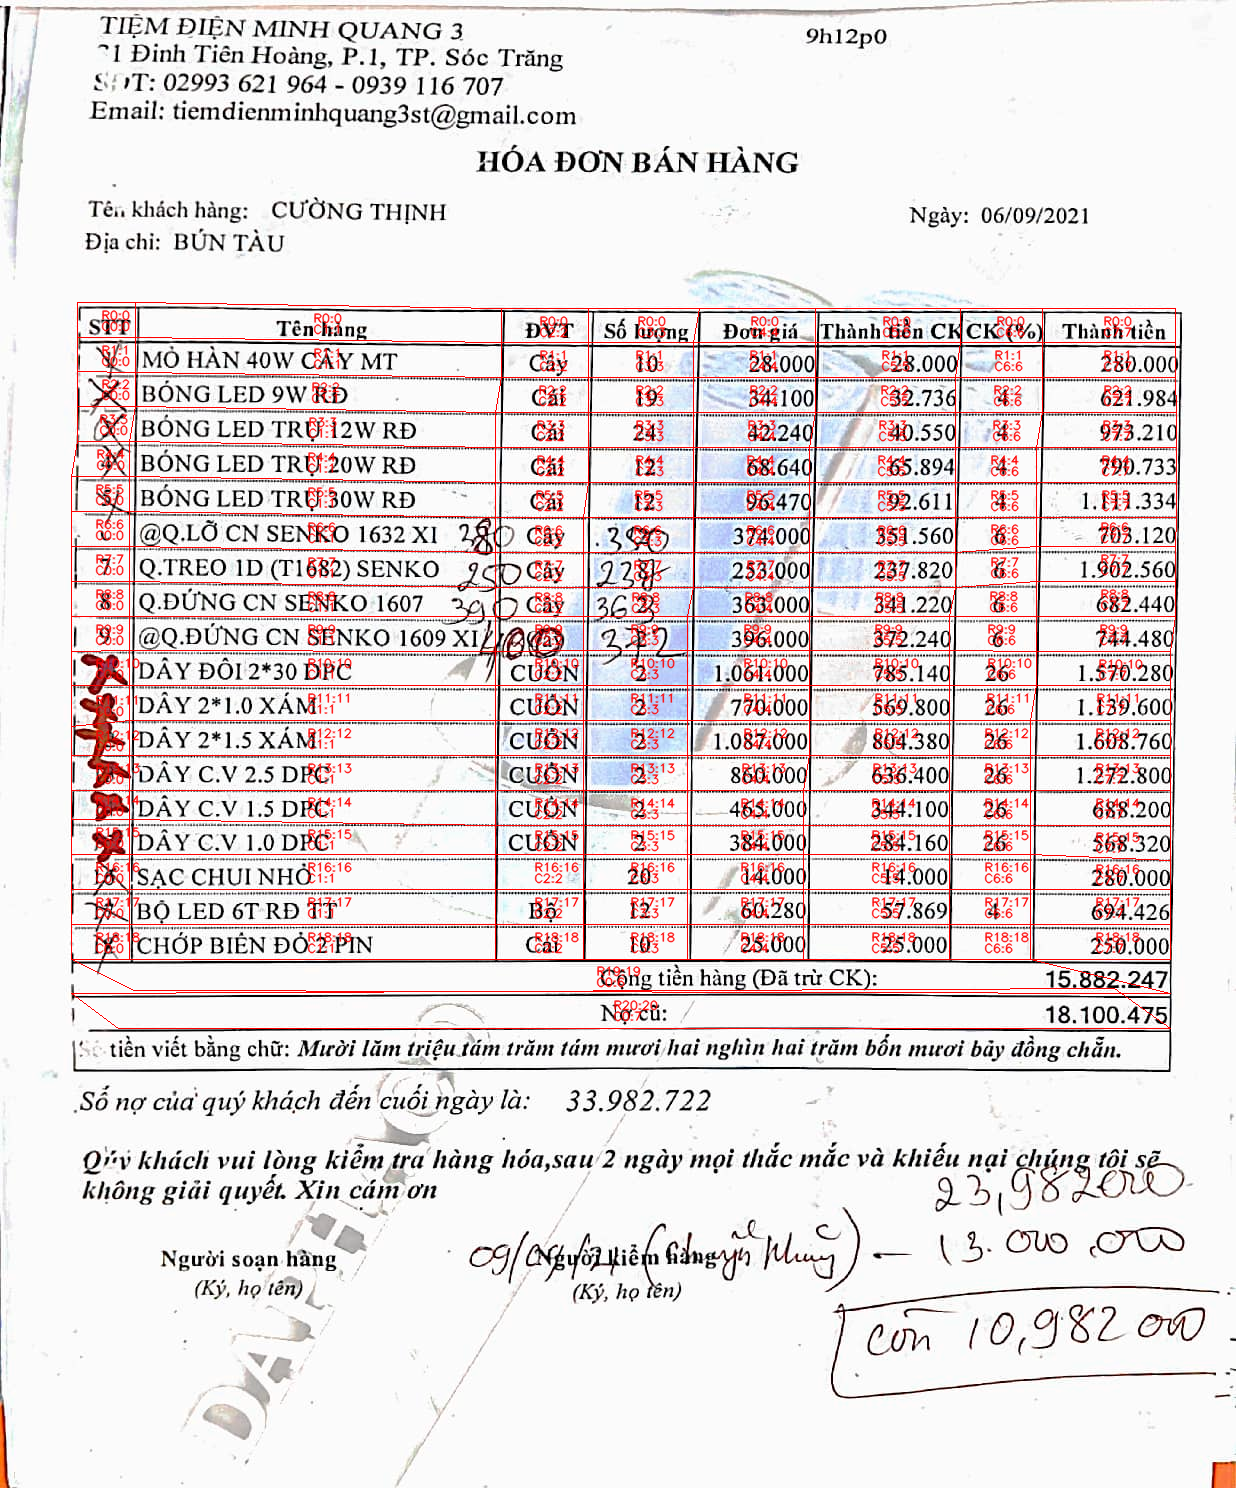

In [6]:
Image.fromarray(plot_img)

In [48]:
opt2 = {'task': 'ctdet', 
       'dataset': 'table',
       'dataset_name': 'WTW', 
       'exp_id': 'default', 
       'test': False, 
       'hold_det': False, 
       'vis_corner': 0,
       'convert_onnx': 0, 
       'debug': 0, 
       'demo': '', 
       'demo_name': 'demo_wired', 
       'output_dir': '../data/table/', 
       'demo_dir': '../visualization_wired/',
       'demo_output': '', 
       'image_dir': '../data/WTW/full_images',
       'load_model': 'AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/exp/ctdet/finetune2/model_best.pth',
       'load_processor': 'AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/exp/ctdet/finetune2/processor_best.pth',
       'resume': False, 
       'gpus': [0],
       'num_workers': 0, 
       'not_cuda_benchmark': False, 
       'seed': 317, 
       'print_iter': 0, 
       'hide_data_time': False,
       'save_all': False,
       'metric': 'loss',
       'anno_path': '', 
       'cell_thresh': 0.3,
       'vis_thresh': 0.2, 
       'vis_thresh_corner': 0.3, 
       'debugger_theme': 'white',
       'arch': 'dla_34', 
       'head_conv': 256, 
       'down_ratio': 4,
       'load_mode': 'single',
       'wiz_2dpe': False, 
       'wiz_4ps': True, 
       'wiz_stacking': True,
       'input_size': 256,
       'hidden_size': 256, 
       'output_size': 4,
       'tsfm_layers': 4,
       'stacking_layers': 4, 
       'num_heads': 8,
       'att_dropout': 0.1,
       'max_fmp_size': 256,
       'input_res': 1024, 
       'input_h': 1024,
       'input_w': 1024,
       'lr': 0.000125, 
       'lr_step': [80],
       'num_epochs': 90, 'batch_size': 1, 'master_batch_size': 1, 'num_iters': -1, 'val_intervals': 5, 'trainval': False, 'full_loss': False, 'upper_left': False, 'wiz_pairloss': False, 'wiz_dsloss': False, 'flip_test': False, 'save_path': '../data/dingding_shiyu/', 'test_scales': [1.0], 'nms': False, 'K': 3000, 'not_prefetch_test': False, 'thresh_min': 0.5, 'thresh_max': 0.7, 'thresh_conf': 0.1, 'fix_res': True, 'keep_res': False, 'wiz_rev': True, 'wiz_detect': True, 'not_rand_crop': False, 'shift': 0.1, 'scale': 0.4, 'rotate': 0, 'flip': 0.5, 'no_color_aug': False, 'MK': '5000', 'aug_rot': 0, 'aug_ddd': 0.5, 'rect_mask': False, 'kitti_split': '3dop', 'mse_loss': False, 'reg_loss': 'l1', 'hm_weight': 1, 'mk_weight': 1, 'off_weight': 1, 'wh_weight': 1, 'st_weight': 1, 'hp_weight': 1, 'hm_hp_weight': 1, 'dep_weight': 1, 'dim_weight': 1, 'rot_weight': 1, 'peak_thresh': 0.1, 'norm_wh': False, 'dense_wh': False, 'cat_spec_wh': False, 'not_reg_offset': False, 'agnostic_ex': False, 'scores_thresh': 0.2, 'center_thresh': 0.1, 'aggr_weight': 0.0, 'dense_hp': False, 'not_hm_hp': False, 'not_reg_hp_offset': False, 'not_reg_bbox': False, 'eval_oracle_hm': False, 'eval_oracle_mk': False, 'eval_oracle_wh': False, 'eval_oracle_offset': False, 'eval_oracle_kps': False, 'eval_oracle_hmhp': False, 'eval_oracle_hp_offset': False, 'eval_oracle_dep': False, 'gpus_str': '0', 'reg_offset': True, 'reg_bbox': True, 'hm_hp': True, 'reg_hp_offset': True, 'pad': 31, 'num_stacks': 1, 'chunk_sizes': [1], 'root_dir': '/raid/phuongdtt/ocr_ral_v2/AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/src/lib/../..', 'data_dir': '/raid/phuongdtt/ocr_ral_v2/AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/src/lib/../../data', 'exp_dir': '/raid/phuongdtt/ocr_ral_v2/AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/src/lib/../../exp/ctdet', 'save_dir': '/raid/phuongdtt/ocr_ral_v2/AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/src/lib/../../exp/ctdet/default', 'debug_dir': '/raid/phuongdtt/ocr_ral_v2/AdvancedLiterateMachinery/DocumentUnderstanding/LORE-TSR/src/lib/../../exp/ctdet/default/debug', 'mean': [0.408, 0.447, 0.47], 'std': [0.289, 0.274, 0.278], 'num_classes': 2, 'output_h': 256, 'output_w': 256, 'output_res': 256, 'heads': {'hm': 2, 'st': 8, 'wh': 8, 'ax': 256, 'cr': 256, 'reg': 2}}
opt = argparse.Namespace(**opt2)